In [1]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [2]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [3]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_valid = scl.transform(X_valid)
X_test = scl.transform(X_test)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=True)

In [4]:
print(X_train.shape, X_test.shape, X_valid.shape)

torch.Size([11610, 8]) torch.Size([5160, 8]) torch.Size([3870, 8])


In [5]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

Epoch: 1/1000, Train Loss: 2.143, Train Metric: 0.896, Valid Metric: 0.61, Learning Rate: 0.633,Time: 2.13s
	Checkpoint, valid metric : 0.610
Epoch: 2/1000, Train Loss: 0.541, Train Metric: 0.543, Valid Metric: 0.557, Learning Rate: 0.459,Time: 1.31s
	Checkpoint, valid metric : 0.557
Epoch: 3/1000, Train Loss: 0.441, Train Metric: 0.48, Valid Metric: 0.468, Learning Rate: 0.242,Time: 1.33s
	Checkpoint, valid metric : 0.468
Epoch: 4/1000, Train Loss: 0.4, Train Metric: 0.453, Valid Metric: 0.469, Learning Rate: 0.068,Time: 1.6s
Epoch: 5/1000, Train Loss: 0.378, Train Metric: 0.436, Valid Metric: 0.434, Learning Rate: 0.700,Time: 1.92s
	Checkpoint, valid metric : 0.434
Epoch: 6/1000, Train Loss: 0.604, Train Metric: 0.575, Valid Metric: 0.57, Learning Rate: 0.683,Time: 1.94s
Epoch: 7/1000, Train Loss: 0.512, Train Metric: 0.524, Valid Metric: 0.473, Learning Rate: 0.633,Time: 1.52s
Epoch: 8/1000, Train Loss: 0.461, Train Metric: 0.496, Valid Metric: 0.437, Learning Rate: 0.556,Time: 3.44

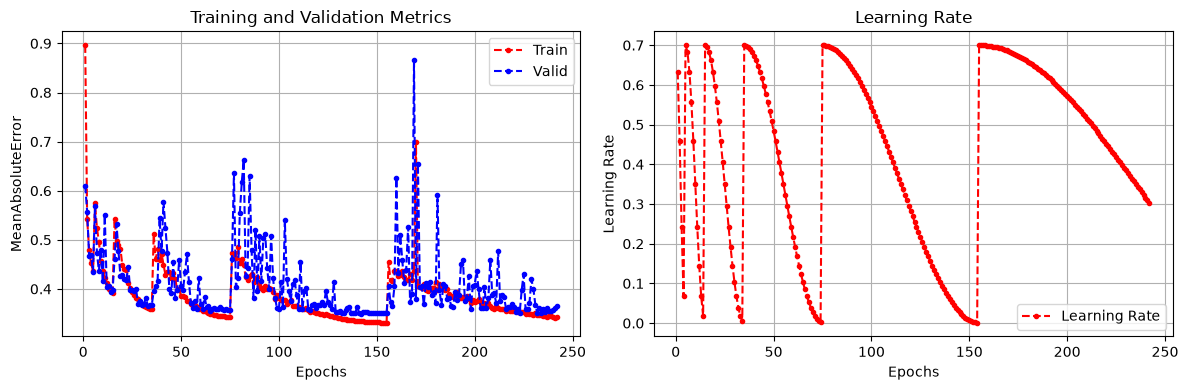

In [6]:
from custom_utils import train, plot_history

class PriceRegressor(nn.Module):
	def __init__(
    	self, 
     	n_features, 
      	hidden_dims=[16, 24, 16, 8],
		use_batchnorm=False,
		dropout_rate=None
    ):
		super().__init__()
		layers = []
		for i, hidden_dim in enumerate(hidden_dims):
			layers.append(nn.Linear(
       			in_features=n_features if i==0 else hidden_dims[i-1], 
          		out_features=hidden_dim, 
            	bias=False if use_batchnorm else True
			))
			layers.append(nn.LeakyReLU())
			if use_batchnorm:
				layers.append(nn.BatchNorm1d(hidden_dim))
			if dropout_rate is not None:
				layers.append(nn.Dropout(dropout_rate))
		layers.append(nn.Linear(
      		in_features=hidden_dims[-1], 
          	out_features=1,
            bias=False if use_batchnorm else True
		))
		self.sequential = nn.Sequential(*layers)
               
	def forward(self, X):
		y = self.sequential(X)
		return y

hidden_dims = [16, 24, 16, 8]
model = PriceRegressor(
    n_features=8, 
    hidden_dims=[16, 24, 16, 8],
    # dropout_rate=0.1
).to(device)

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        if module.bias is not None:
            nn.init.zeros_(module.bias) 
model.apply(use_he_init)

learning_rate = 0.7
n_epochs = 1000
patience = n_epochs // 10
warmup_epochs = patience // 2

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
# optimizer = torch.optim.AdamW(params=model.parameters(), lr=learning_rate)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=warmup_epochs)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=0.001)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	# warmup_scheduler=warmup_scheduler, 
	scheduler=scheduler, 
	patience=patience,
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0,
    )
plot_history(history, metric)